In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/first-inten-project/first inten project.csv')

In [3]:
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [4]:
#check for duplication
df.duplicated().sum()

0

In [5]:
df['date of reservation'] = df['date of reservation'].replace('2018-2-29','3/1/2018')

In [6]:
df['date of reservation']= pd.to_datetime(df['date of reservation'])

In [7]:
df['year of reservation'] = df['date of reservation'].dt.year
df['month of reservation'] = df['date of reservation'].dt.month
df['day of reservation'] = df['date of reservation'].dt.day

In [8]:
df.drop(['Booking_ID','date of reservation'] , axis = 1, inplace = True)

In [9]:
df.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status,year of reservation,month of reservation,day of reservation
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,Not_Canceled,2015,10,2
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled,2018,11,6
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,Canceled,2018,2,28
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,Canceled,2017,5,20
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,Canceled,2018,4,11


In [10]:
df.shape

(36285, 18)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   number of adults          36285 non-null  int64  
 1   number of children        36285 non-null  int64  
 2   number of weekend nights  36285 non-null  int64  
 3   number of week nights     36285 non-null  int64  
 4   type of meal              36285 non-null  object 
 5   car parking space         36285 non-null  int64  
 6   room type                 36285 non-null  object 
 7   lead time                 36285 non-null  int64  
 8   market segment type       36285 non-null  object 
 9   repeated                  36285 non-null  int64  
 10  P-C                       36285 non-null  int64  
 11  P-not-C                   36285 non-null  int64  
 12  average price             36285 non-null  float64
 13  special requests          36285 non-null  int64  
 14  bookin

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
number of adults,36285.0,1.844839,0.518813,0.0,2.0,2.00,2.0,4.0
number of children,36285.0,0.105360,0.402704,0.0,0.0,0.00,0.0,10.0
number of weekend nights,36285.0,0.810693,0.870590,0.0,0.0,1.00,2.0,7.0
number of week nights,36285.0,2.204602,1.410946,0.0,1.0,2.00,3.0,17.0
car parking space,36285.0,0.030977,0.173258,0.0,0.0,0.00,0.0,1.0
lead time,36285.0,85.239851,85.938796,0.0,17.0,57.00,126.0,443.0
repeated,36285.0,0.025630,0.158032,0.0,0.0,0.00,0.0,1.0
P-C,36285.0,0.023343,0.368281,0.0,0.0,0.00,0.0,13.0
P-not-C,36285.0,0.153369,1.753931,0.0,0.0,0.00,0.0,58.0
average price,36285.0,103.421636,35.086469,0.0,80.3,99.45,120.0,540.0


In [13]:
df.describe(include= 'O').T

,count,unique,top,freq
type of meal,36285,4,Meal Plan 1,27842
room type,36285,7,Room_Type 1,28138
market segment type,36285,5,Online,23221
booking status,36285,2,Not_Canceled,24396


In [14]:
#check for missing values
df.isnull().sum()

number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
booking status              0
year of reservation         0
month of reservation        0
day of reservation          0
dtype: int64

In [15]:
#check for duplication
df.duplicated().sum()

10276

In [16]:
df.columns

Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'type of meal', 'car parking space',
       'room type', 'lead time', 'market segment type', 'repeated', 'P-C',
       'P-not-C', 'average price ', 'special requests', 'booking status',
       'year of reservation', 'month of reservation', 'day of reservation'],
      dtype='object')

In [17]:
categorical_columns = ['type of meal','room type','market segment type','booking status']

In [18]:
for col in categorical_columns:
    print(df[col].value_counts())
    print("-------------------------")
    print(' ')

type of meal
Meal Plan 1     27842
Not Selected     5132
Meal Plan 2      3306
Meal Plan 3         5
Name: count, dtype: int64
-------------------------
 
room type
Room_Type 1    28138
Room_Type 4     6059
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64
-------------------------
 
market segment type
Online           23221
Offline          10531
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64
-------------------------
 
booking status
Not_Canceled    24396
Canceled        11889
Name: count, dtype: int64
-------------------------
 


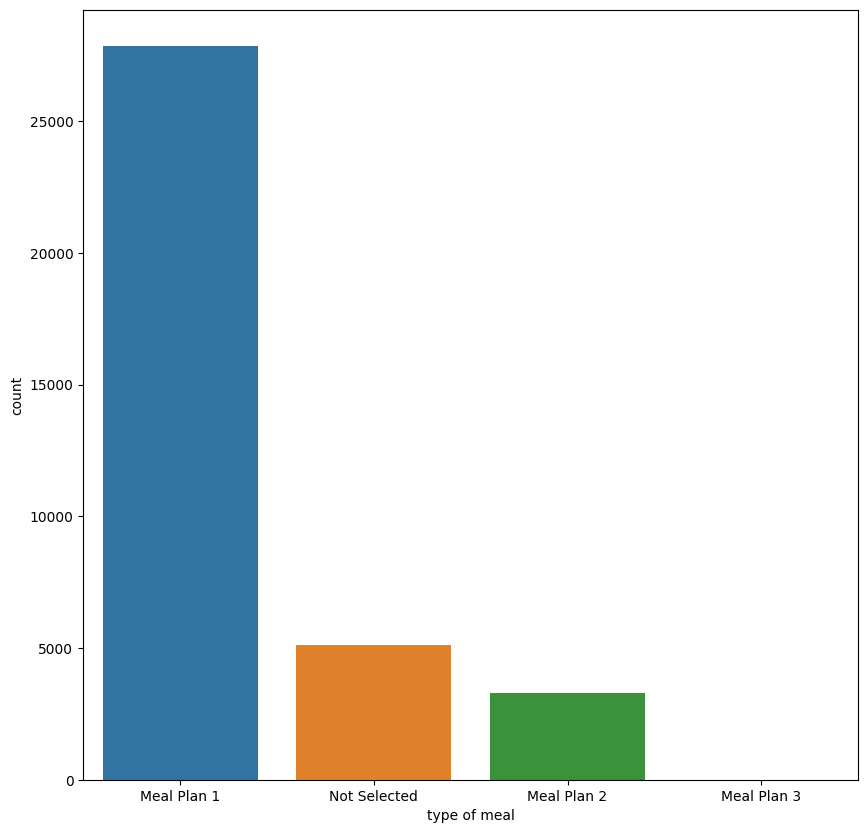

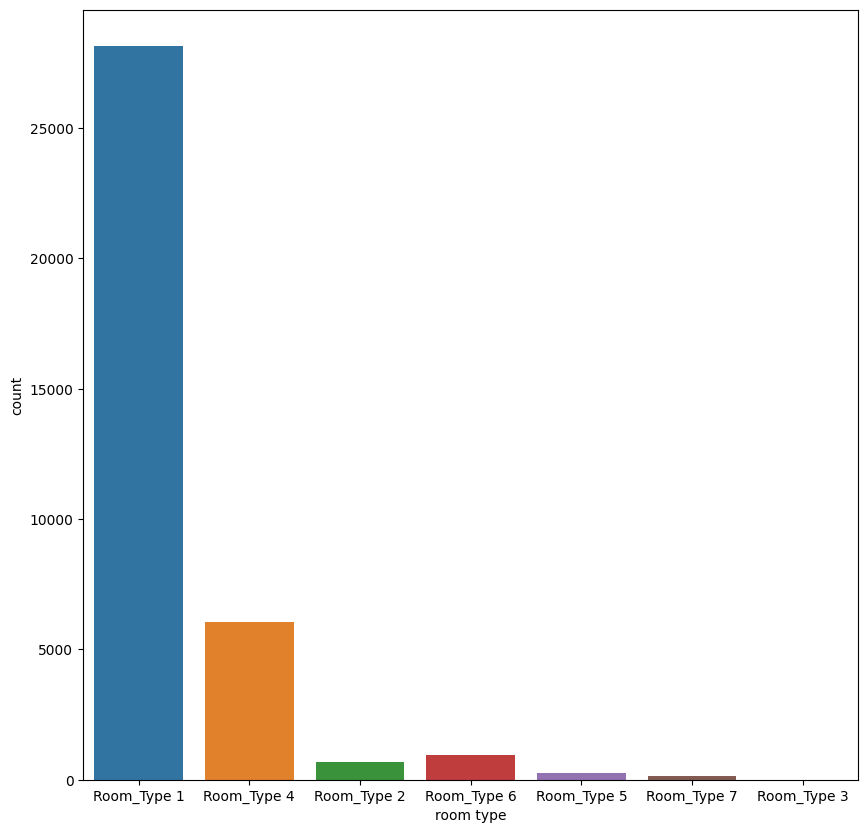

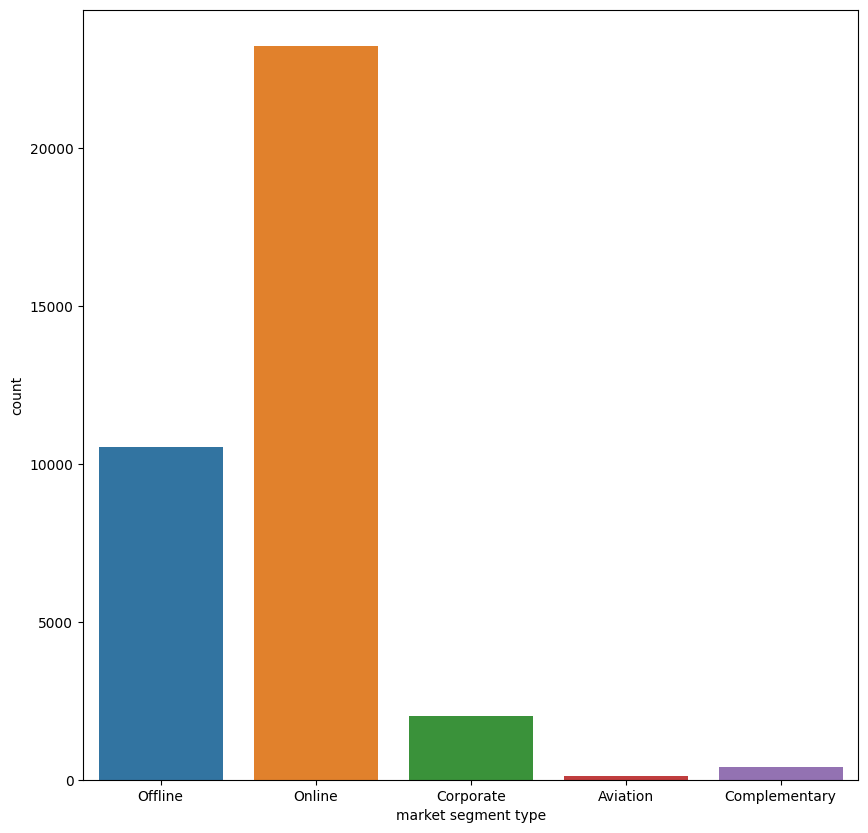

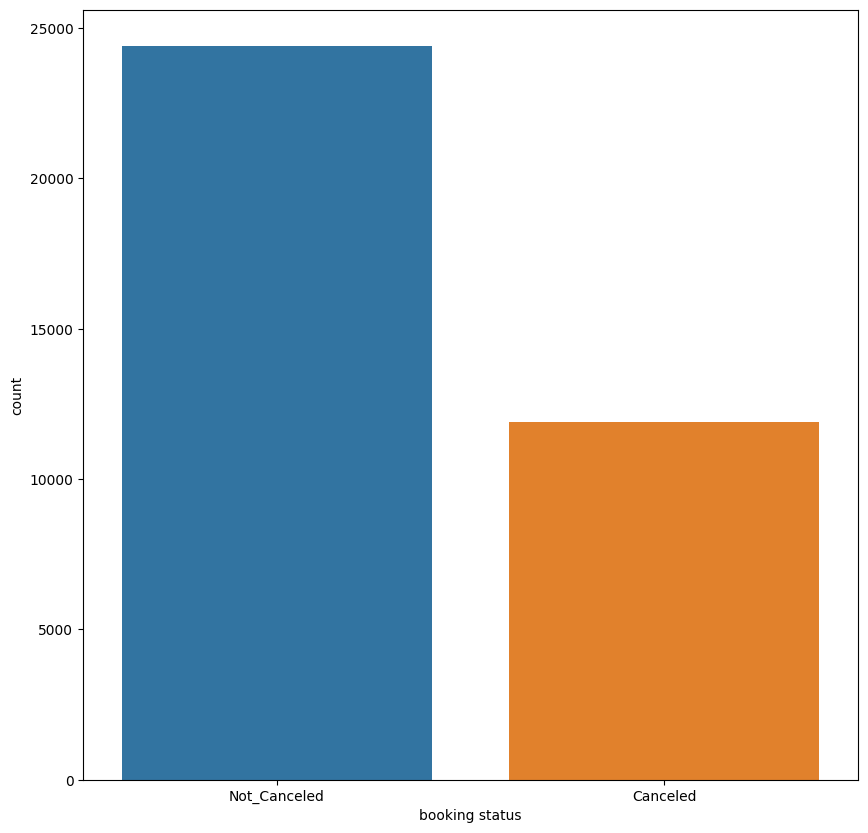

In [19]:
for col in categorical_columns:
    plt.figure(figsize=(10, 10))
    sns.countplot(data = df , x =col)
    plt.show()

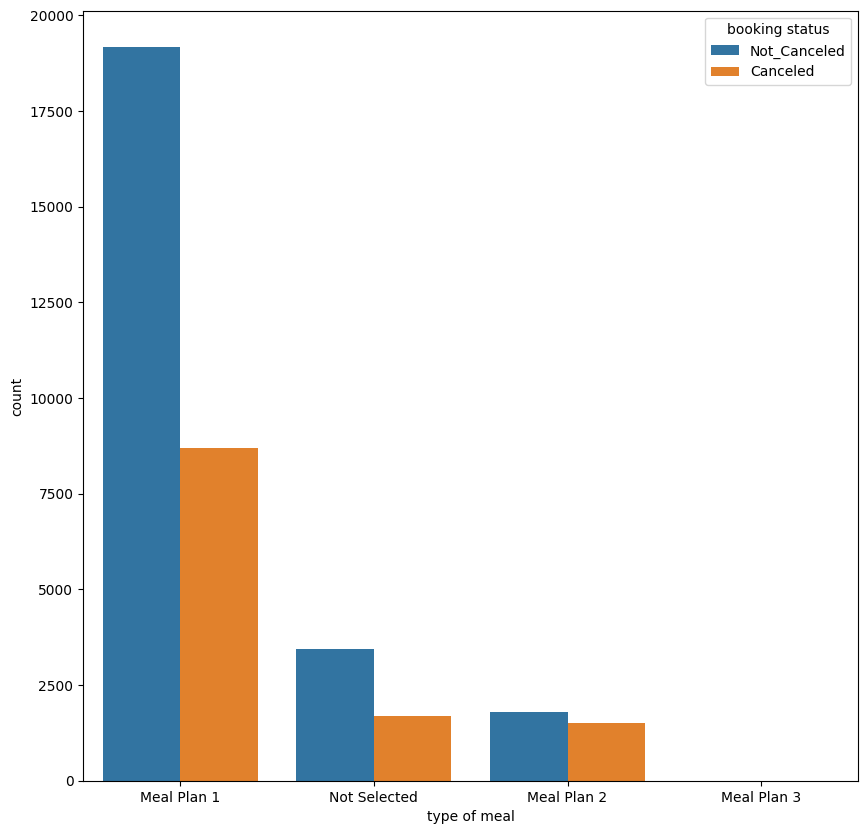

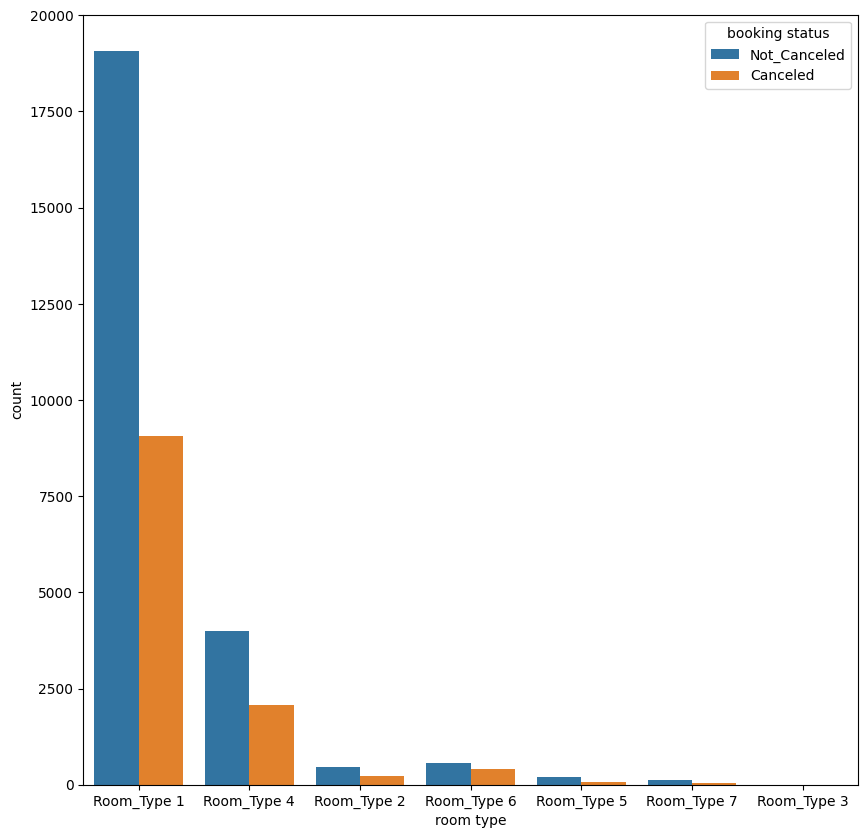

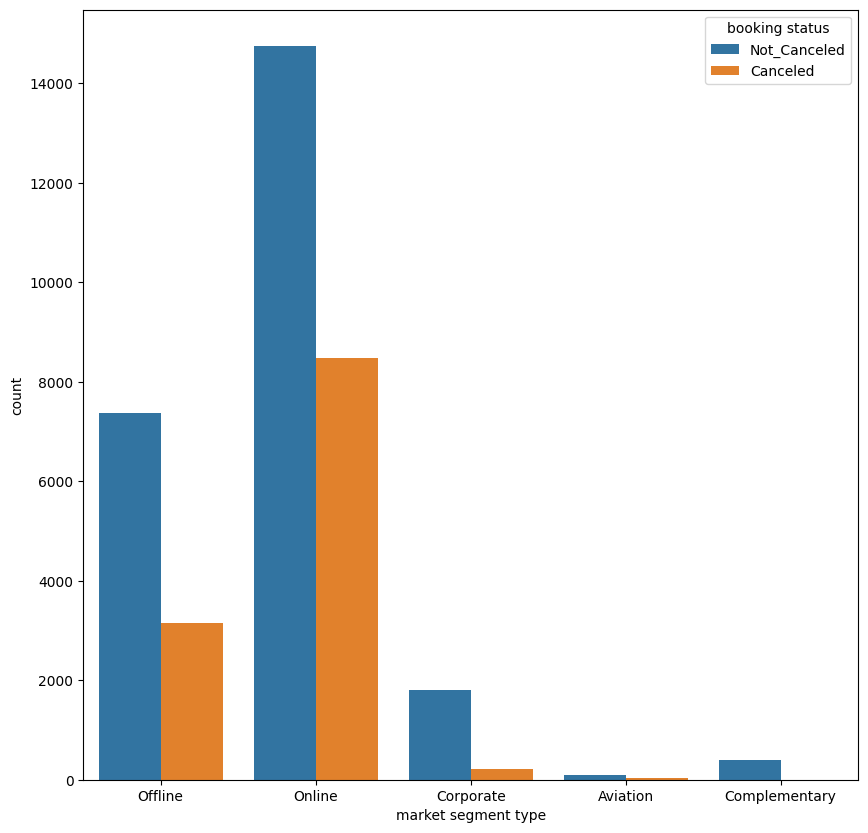

In [20]:
for col in ['type of meal','room type','market segment type']:
    plt.figure(figsize=(10, 10))
    sns.countplot(data = df, x =col,hue = 'booking status')
    plt.show()

In [21]:
df.columns

Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'type of meal', 'car parking space',
       'room type', 'lead time', 'market segment type', 'repeated', 'P-C',
       'P-not-C', 'average price ', 'special requests', 'booking status',
       'year of reservation', 'month of reservation', 'day of reservation'],
      dtype='object')

In [22]:
continuous_cols=['lead time','average price ']

discrete_cols=['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights','car parking space','repeated', 'P-C','year of reservation', 'month of reservation', 'day of reservation','P-not-C',
        'special requests']

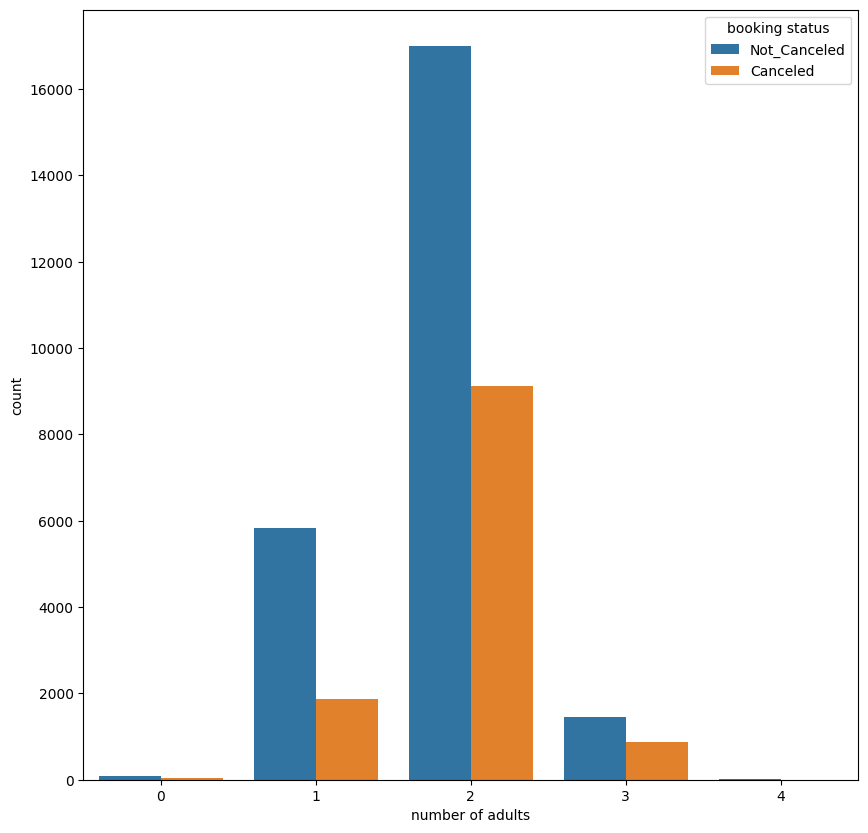

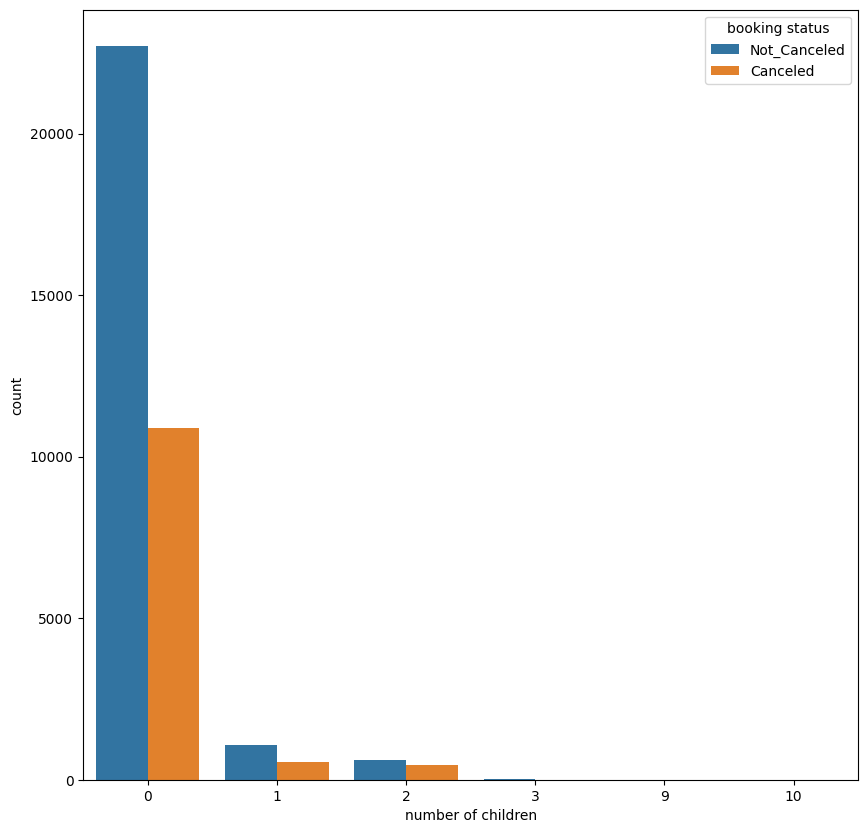

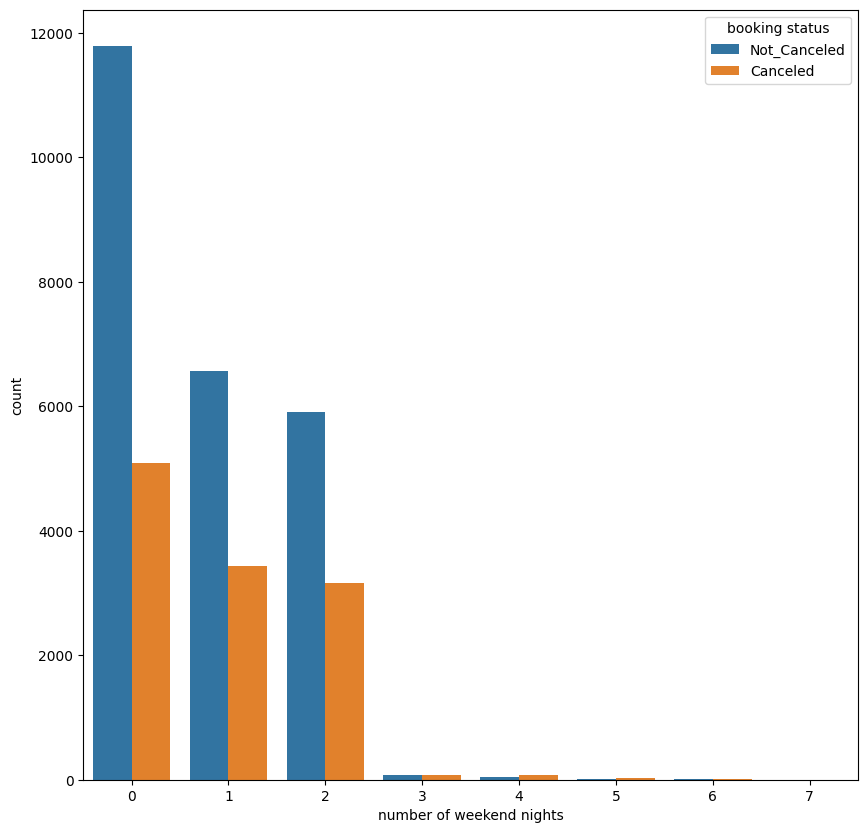

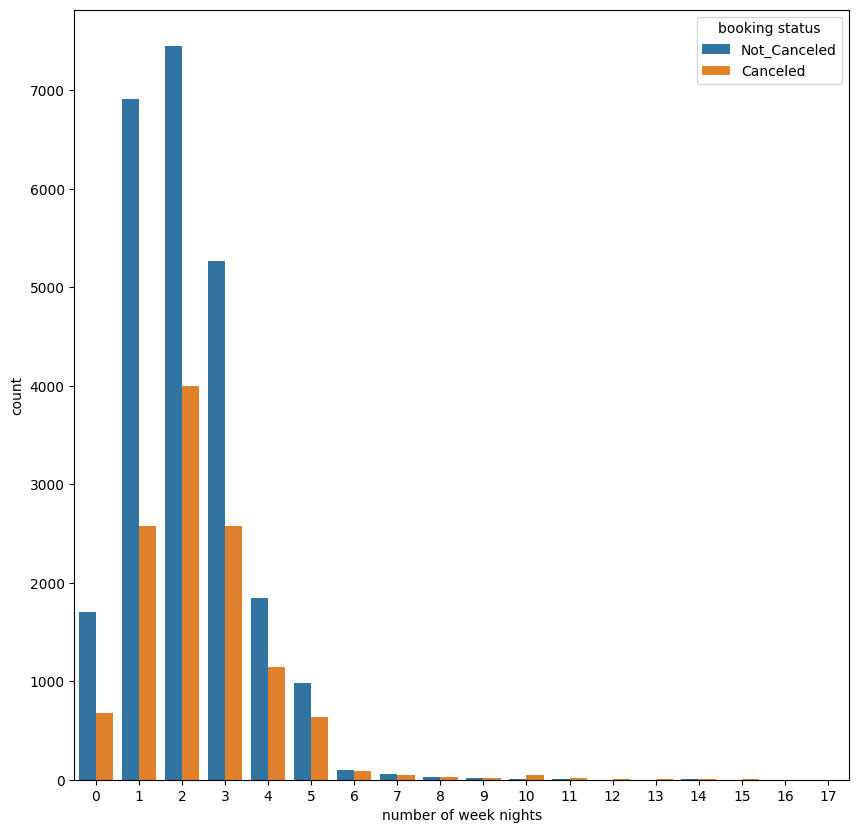

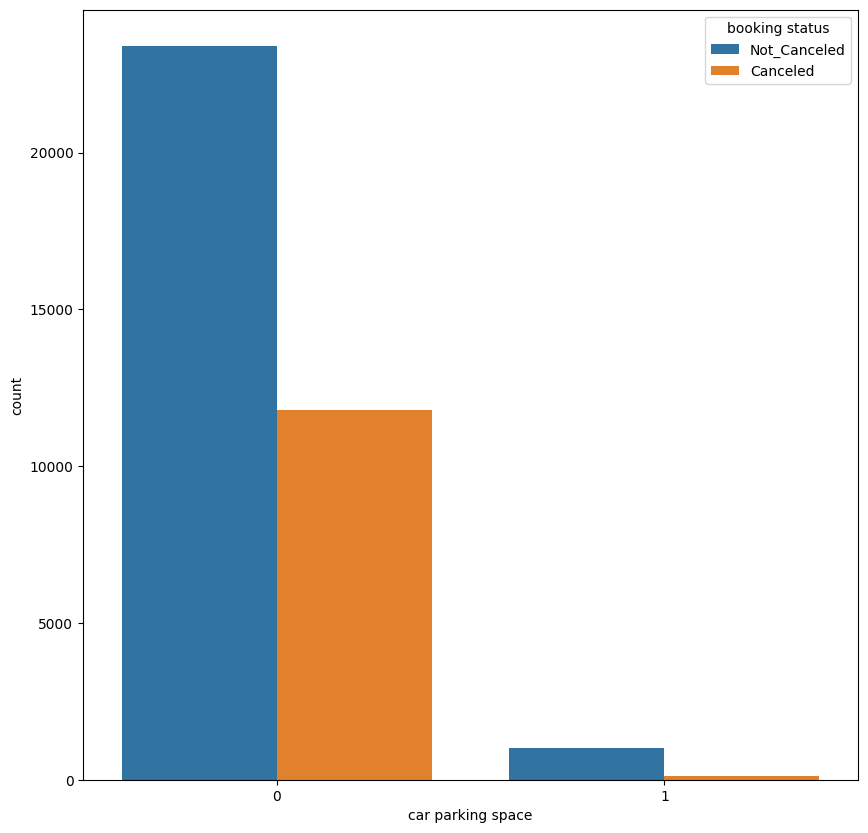

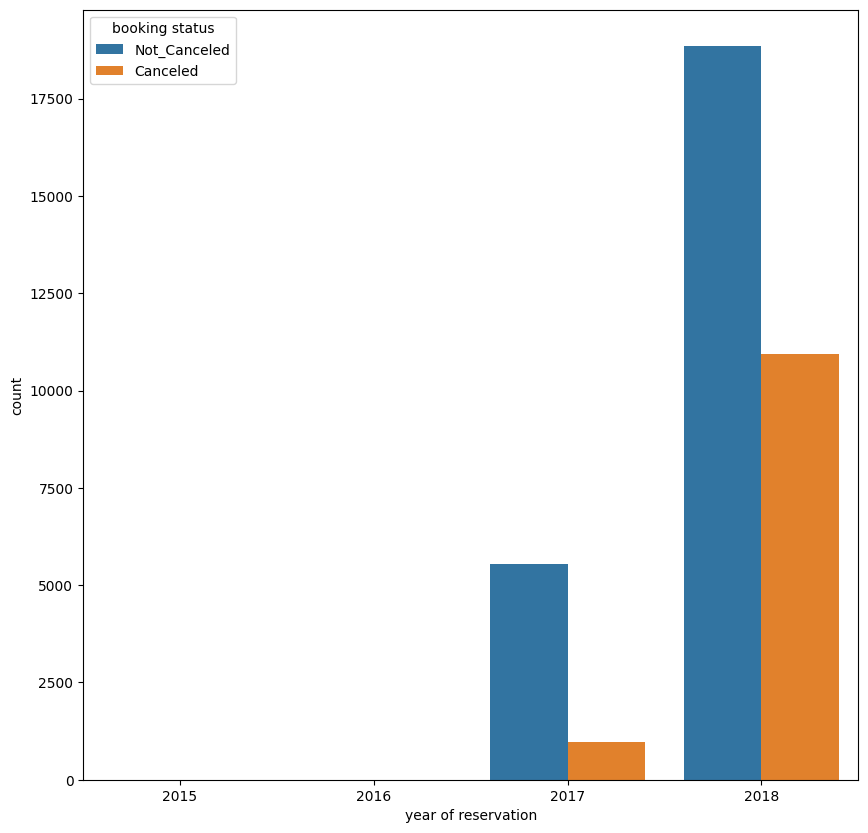

In [23]:
for col in ['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'car parking space','year of reservation']:
    plt.figure(figsize=(10, 10))
    sns.countplot(data = df, x =col,hue = 'booking status')
    plt.show()

In [24]:
for col in discrete_cols:
    print(df[col].value_counts())
    print("-------------------------")
    print(' ')

number of adults
2    26110
1     7702
3     2318
0      139
4       16
Name: count, dtype: int64
-------------------------
 
number of children
0     33583
1      1622
2      1058
3        19
9         2
10        1
Name: count, dtype: int64
-------------------------
 
number of weekend nights
0    16876
1    10000
2     9072
3      153
4      129
5       34
6       20
7        1
Name: count, dtype: int64
-------------------------
 
number of week nights
2     11447
1      9488
3      7842
4      2992
0      2387
5      1616
6       189
7       113
10       62
8        62
9        34
11       17
15       10
12        9
14        7
13        5
17        3
16        2
Name: count, dtype: int64
-------------------------
 
car parking space
0    35161
1     1124
Name: count, dtype: int64
-------------------------
 
repeated
0    35355
1      930
Name: count, dtype: int64
-------------------------
 
P-C
0     35947
1       198
2        46
3        43
11       25
5        11
4        10
13 

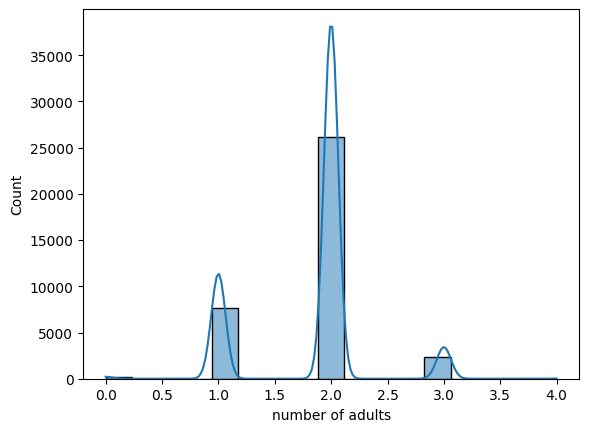

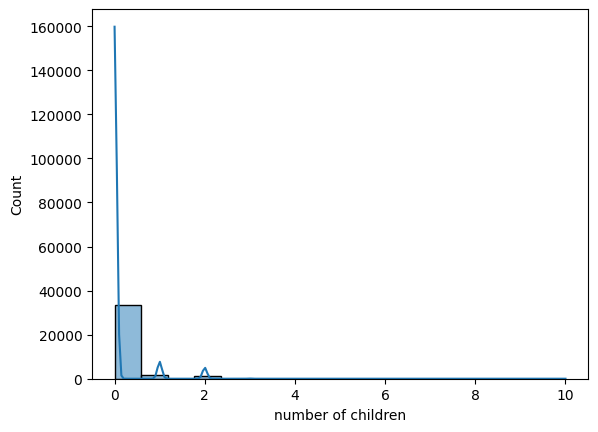

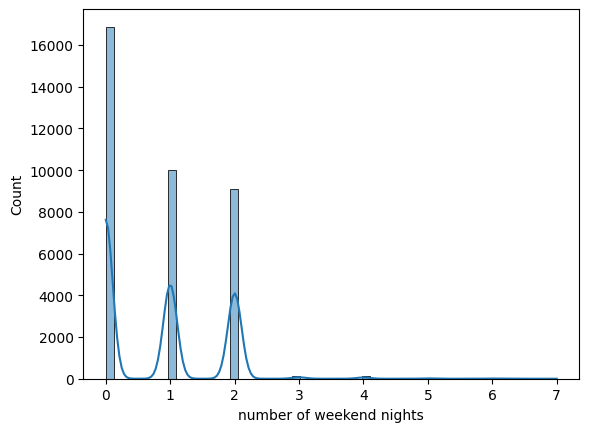

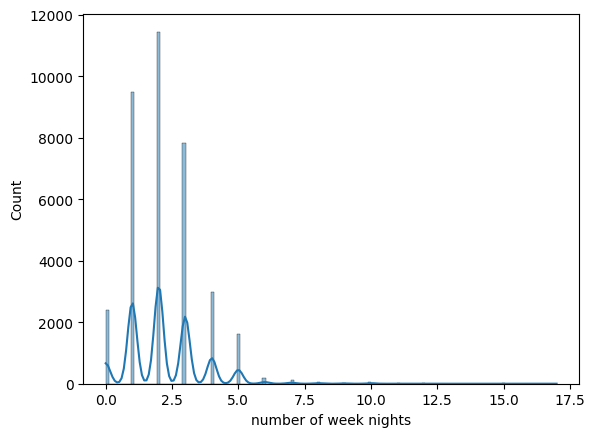

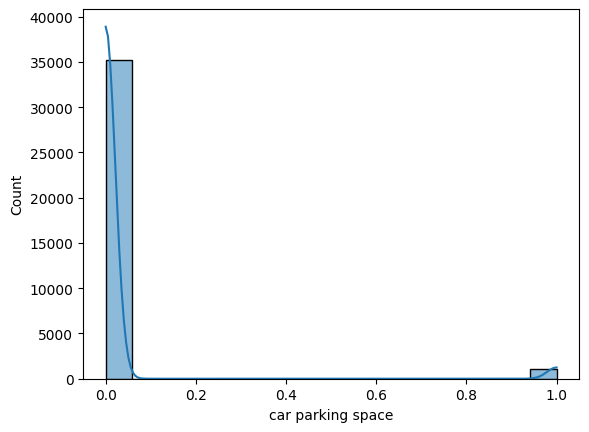

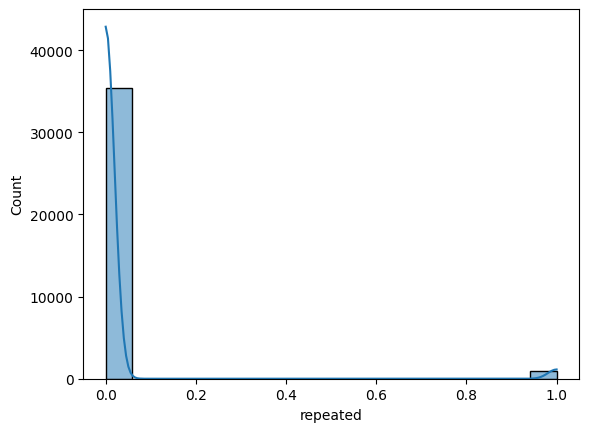

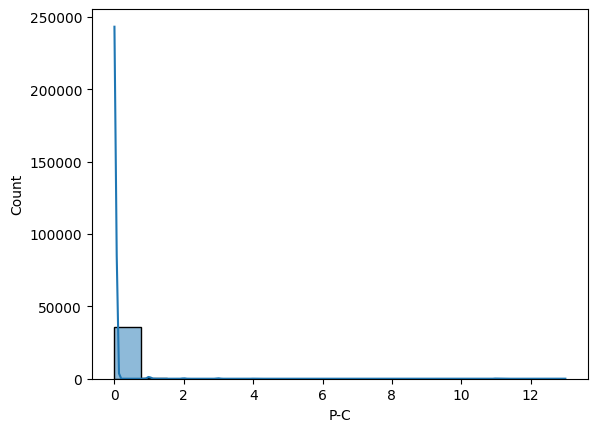

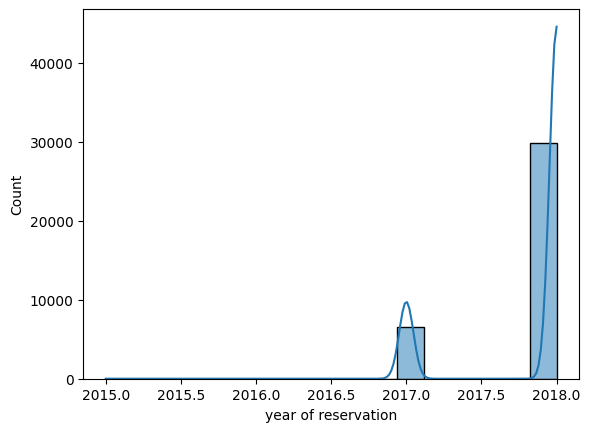

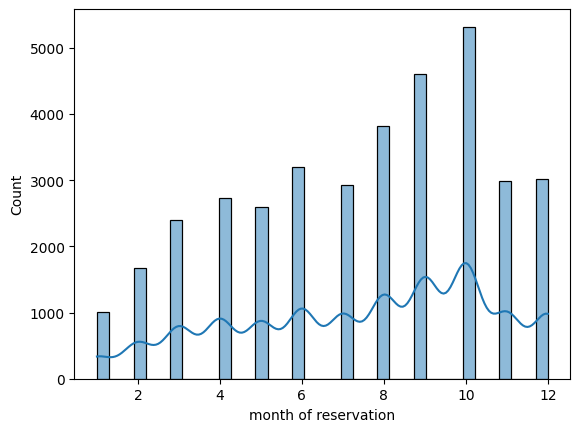

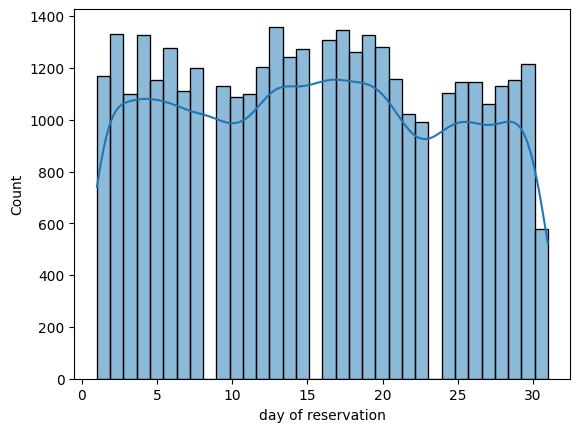

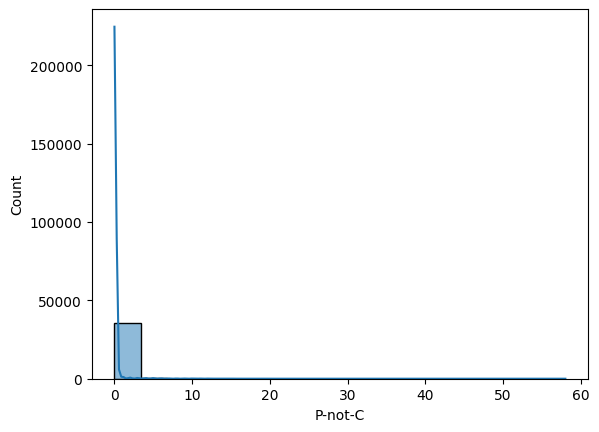

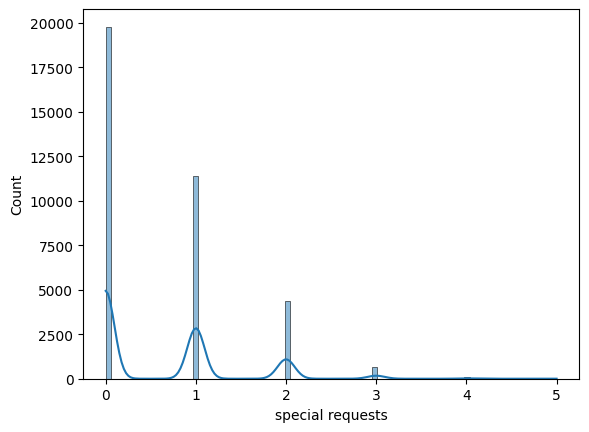

In [25]:
for col in discrete_cols:
    sns.histplot(data = df , x =col, kde=True)
    plt.show()



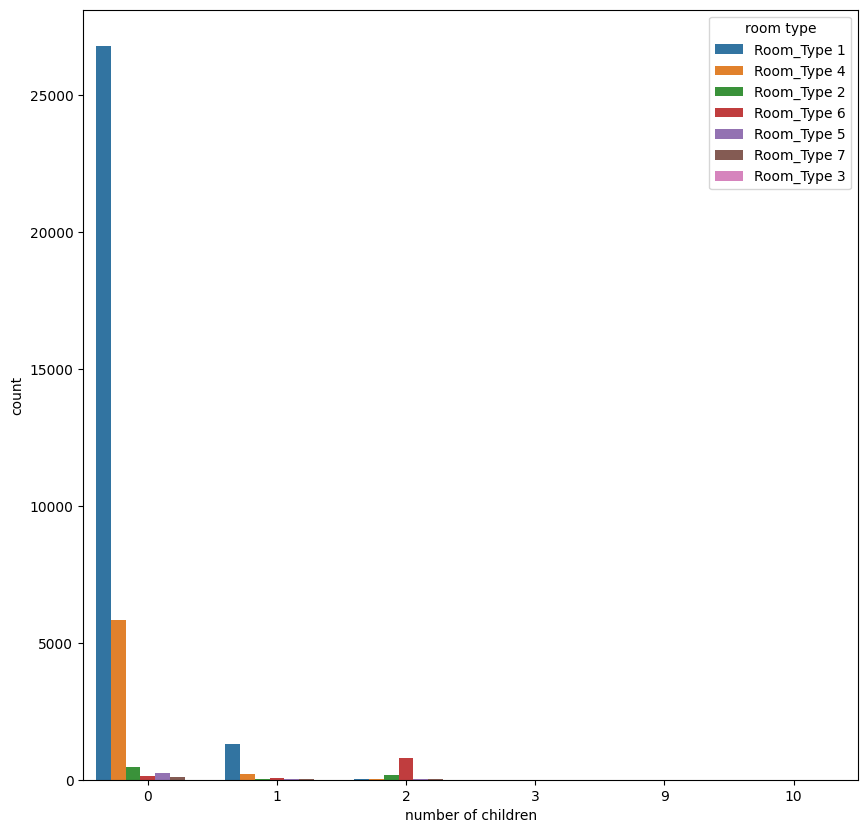

In [26]:
plt.figure(figsize=(10, 10))
sns.countplot(data = df, x='number of children', hue='room type')
plt.show()

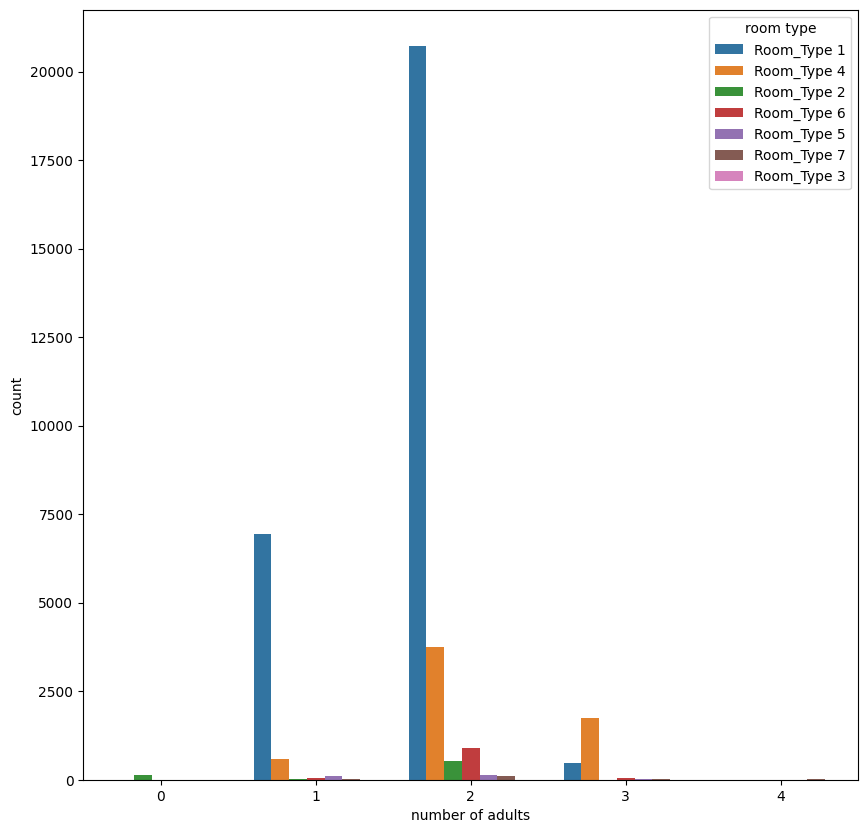

In [27]:
plt.figure(figsize=(10, 10))
sns.countplot(data = df, x='number of adults', hue='room type')
plt.show()

In [28]:
df.columns

Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'type of meal', 'car parking space',
       'room type', 'lead time', 'market segment type', 'repeated', 'P-C',
       'P-not-C', 'average price ', 'special requests', 'booking status',
       'year of reservation', 'month of reservation', 'day of reservation'],
      dtype='object')

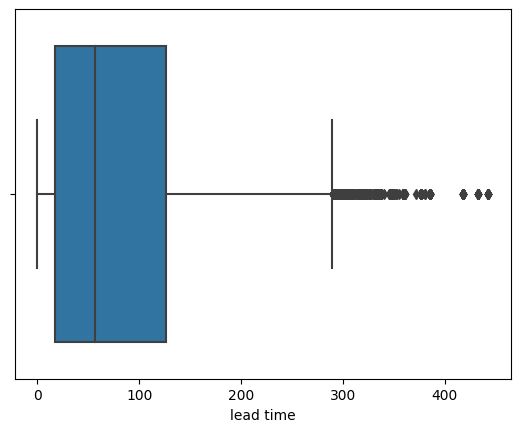

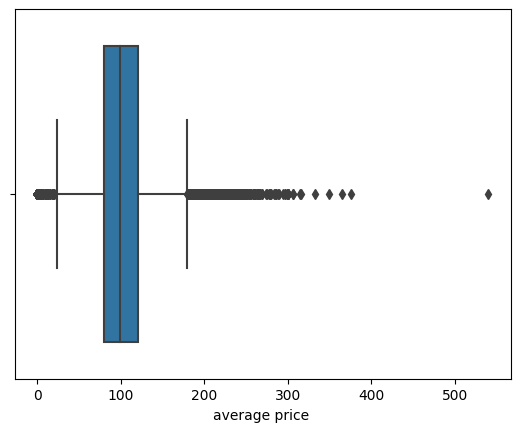

In [29]:
#outliers
for col in continuous_cols:
    sns.boxplot(data = df , x =col)
    plt.show()

In [30]:
for col in continuous_cols:
    print(df[col].quantile([0.7,0.8,0.9,0.95,0.99,0.995,0.999,1]))
    print("-------------------------")
    print(' ')
    

0.700    108.0
0.800    151.0
0.900    213.0
0.950    273.0
0.990    346.0
0.995    377.0
0.999    433.0
1.000    443.0
Name: lead time, dtype: float64
-------------------------
 
0.700    116.00000
0.800    129.00000
0.900    147.59000
0.950    165.00000
0.990    208.00000
0.995    224.67000
0.999    265.31504
1.000    540.00000
Name: average price , dtype: float64
-------------------------
 


In [31]:
def outliers_handling(x, p1=0.25, p2=0.75):
    q1= x.quantile(p1)
    q3= x.quantile(p2)

    iqr = q3 - q1
    min_limit = (q1 - 1.5 * iqr)
    max_limit = (q3 + 1.5 * iqr)
    # Upper bound
    upper = df[x >= max_limit].index
    # Lower bound
    lower = df[x <= min_limit].index
    
    # Removing the Outliers
    df.drop(upper, inplace = True)
    df.drop(lower, inplace = True)

In [32]:
for col in continuous_cols:
    outliers_handling(df[col])

In [33]:
df.shape

(33345, 18)

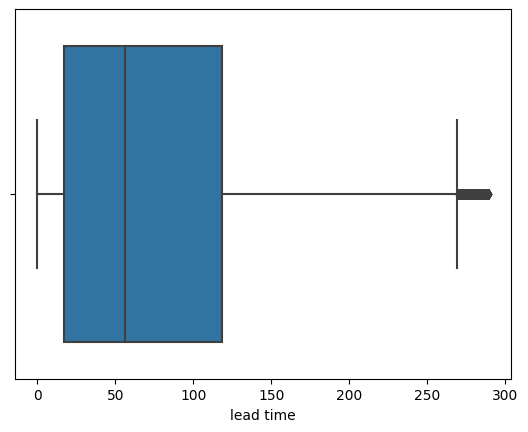

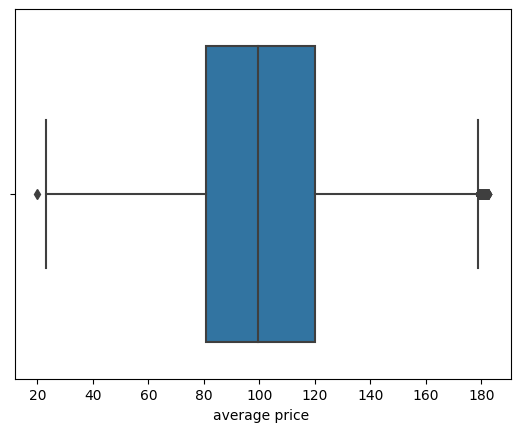

In [34]:
for col in continuous_cols:
    sns.boxplot(data = df , x =col)
    plt.show()

In [35]:
#ُEncoding
from sklearn.preprocessing import LabelEncoder
lb_encoder = LabelEncoder()
for col in categorical_columns:
    df[col]= lb_encoder.fit_transform(df[col])


In [36]:
for col in categorical_columns:
    print(df[col].value_counts())
    print("-------------------------")
    print(' ')

type of meal
0    25802
2     5069
1     2474
Name: count, dtype: int64
-------------------------
 
room type
0    26267
3     5746
1      624
5      463
4      218
6       22
2        5
Name: count, dtype: int64
-------------------------
 
market segment type
4    21736
3     9460
2     2007
0      125
1       17
Name: count, dtype: int64
-------------------------
 
booking status
1    22921
0    10424
Name: count, dtype: int64
-------------------------
 


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33345 entries, 0 to 36284
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   number of adults          33345 non-null  int64  
 1   number of children        33345 non-null  int64  
 2   number of weekend nights  33345 non-null  int64  
 3   number of week nights     33345 non-null  int64  
 4   type of meal              33345 non-null  int64  
 5   car parking space         33345 non-null  int64  
 6   room type                 33345 non-null  int64  
 7   lead time                 33345 non-null  int64  
 8   market segment type       33345 non-null  int64  
 9   repeated                  33345 non-null  int64  
 10  P-C                       33345 non-null  int64  
 11  P-not-C                   33345 non-null  int64  
 12  average price             33345 non-null  float64
 13  special requests          33345 non-null  int64  
 14  booking sta

In [38]:
x = df.drop(['booking status'], axis = 1)
y =  df['booking status']

In [39]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [40]:
#Hande imbalance data
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

In [41]:
#Scaling
standard_scaler = StandardScaler()

x_train = standard_scaler.fit_transform(x_train)
x_test = standard_scaler .fit_transform(x_test)

In [42]:
models = {
    'LogisticRegression' : LogisticRegression(),
    'DecisionTreeClassifier' : DecisionTreeClassifier(),
    'RandomForestClassifier' : RandomForestClassifier(n_estimators=100, random_state=42)
}

In [43]:
def evalute_model(actual, pred):
    report = classification_report(actual, pred)
    return report

In [44]:
def cm_visualize(y_test, y_pred):
    cm = confusion_matrix(y_test, test_pred)
   
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Canceled", "Canceled"], yticklabels=["Not Canceled", "Canceled"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

LogisticRegression
Accuracy: 72.81%
Model Testing Performance : 
              precision    recall  f1-score   support

           0       0.54      0.84      0.66      2085
           1       0.90      0.68      0.77      4584

    accuracy                           0.73      6669
   macro avg       0.72      0.76      0.72      6669
weighted avg       0.79      0.73      0.74      6669



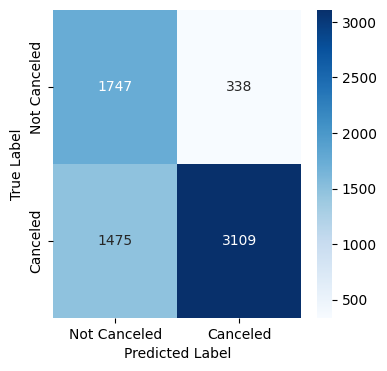

 
**********************************************
DecisionTreeClassifier
Accuracy: 78.23%
Model Testing Performance : 
              precision    recall  f1-score   support

           0       0.62      0.77      0.69      2085
           1       0.88      0.79      0.83      4584

    accuracy                           0.78      6669
   macro avg       0.75      0.78      0.76      6669
weighted avg       0.80      0.78      0.79      6669



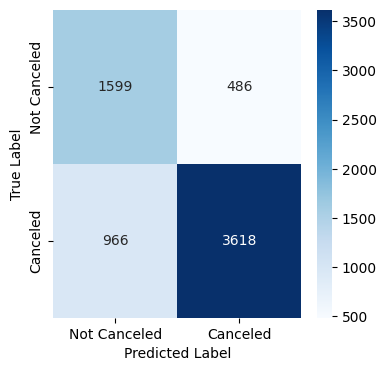

 
**********************************************
RandomForestClassifier
Accuracy: 85.84%
Model Testing Performance : 
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      2085
           1       0.92      0.87      0.89      4584

    accuracy                           0.86      6669
   macro avg       0.83      0.85      0.84      6669
weighted avg       0.87      0.86      0.86      6669



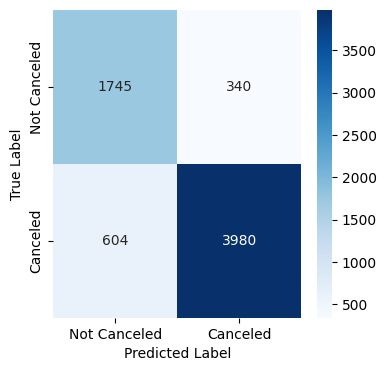

 
**********************************************


In [45]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    #fit model
    model.fit(x_train, y_train)
    
    #model ---> predict
    test_pred = model.predict(x_test)
    train_pred = model.predict(x_train)
    
    #evaluate_model
    accuracy = accuracy_score(y_test, test_pred)
    test_report = evalute_model(y_test, test_pred)
    
    print(list(models.keys())[i])
    print(f'Accuracy: {accuracy * 100:.2f}%')
    
    print("Model Testing Performance : ")
    print(test_report)

    cm_visualize(y_test, test_pred)
    print(' ')
    print("**********************************************")